In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

In [2]:
df = pd.read_csv("Twitter Sentiments.csv")

In [3]:
df

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [5]:
def clean_tweet(text):
    text = str(text)
    text = re.sub(r'@\w+','', text)
    text = re.sub(r'#\w+','', text)
    text = re.sub(r'http\S+|www\S+','', text)
    text = re.sub(r'[^a-zA-z\s]','', text)
    text = text.lower()
    text = re.sub(r'\s+',' ', text).strip()
    return text
df["cleaned_tweet"] =df["tweet"].apply(clean_tweet) 
    
    
    

In [6]:
df.head()

,id,label,tweet,cleaned_tweet
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so selfi...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for credit i cant use cause they dont o...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,i love u take with u all the time in ur
4,5,0,factsguide: society now #motivation,factsguide society now


In [7]:
from nltk.tokenize import word_tokenize
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
df["tokenized"] = df["cleaned_tweet"].apply(word_tokenize)

In [9]:
df.head()

,id,label,tweet,cleaned_tweet,tokenized
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so selfi...,"[when, a, father, is, dysfunctional, and, is, ..."
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for credit i cant use cause they dont o...,"[thanks, for, credit, i, cant, use, cause, the..."
2,3,0,bihday your majesty,bihday your majesty,"[bihday, your, majesty]"
3,4,0,#model i love u take with u all the time in ...,i love u take with u all the time in ur,"[i, love, u, take, with, u, all, the, time, in..."
4,5,0,factsguide: society now #motivation,factsguide society now,"[factsguide, society, now]"


In [10]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [11]:
def stem_words(tokens):
    return[ps.stem(word) for word in tokens]
df["stemmed"] =df["tokenized"].apply(stem_words)

In [12]:

df=df.drop(columns = ["tokenized"])

In [13]:
df.head()

,id,label,tweet,cleaned_tweet,stemmed
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so selfi...,"[when, a, father, is, dysfunct, and, is, so, s..."
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for credit i cant use cause they dont o...,"[thank, for, credit, i, cant, use, caus, they,..."
2,3,0,bihday your majesty,bihday your majesty,"[bihday, your, majesti]"
3,4,0,#model i love u take with u all the time in ...,i love u take with u all the time in ur,"[i, love, u, take, with, u, all, the, time, in..."
4,5,0,factsguide: society now #motivation,factsguide society now,"[factsguid, societi, now]"


In [14]:
df["cleaned_tweet"]= df["stemmed"].apply(lambda x:' '.join(x))
df = df.drop(columns = ["stemmed"])

In [15]:
df.head()

,id,label,tweet,cleaned_tweet
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunct and is so selfish he...
1,2,0,@user @user thanks for #lyft credit i can't us...,thank for credit i cant use caus they dont off...
2,3,0,bihday your majesty,bihday your majesti
3,4,0,#model i love u take with u all the time in ...,i love u take with u all the time in ur
4,5,0,factsguide: society now #motivation,factsguid societi now


In [16]:
df["cleaned_tweet"]=df["cleaned_tweet"].str.strip()

In [17]:
df.head()

,id,label,tweet,cleaned_tweet
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunct and is so selfish he...
1,2,0,@user @user thanks for #lyft credit i can't us...,thank for credit i cant use caus they dont off...
2,3,0,bihday your majesty,bihday your majesti
3,4,0,#model i love u take with u all the time in ...,i love u take with u all the time in ur
4,5,0,factsguide: society now #motivation,factsguid societi now


In [18]:
from wordcloud import WordCloud
all_words = ' '.join(df["cleaned_tweet"])

In [19]:
word_cloud = WordCloud(width=800,height=500,background_color='White',colormap="Set2",max_words=100).generate(all_words)

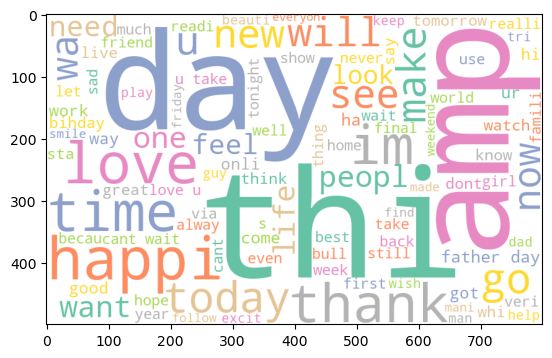

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [22]:
plt.imshow(word_cloud)
plt.show()
plt.figure(figsize=(10,5))

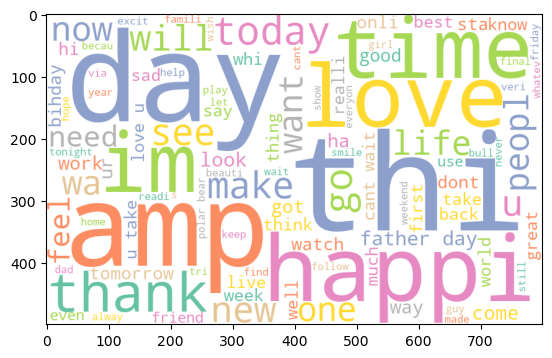

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [23]:
all_words = ' '.join(df["cleaned_tweet"][df["label"]==0])
word_cloud = WordCloud(width=800,height=500,background_color='White',colormap="Set2",max_words=100).generate(all_words)
plt.imshow(word_cloud)
plt.show()
plt.figure(figsize=(10,5))

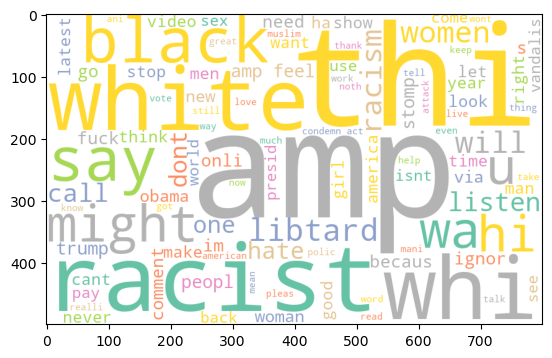

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [24]:
all_words = ' '.join(df["cleaned_tweet"][df["label"]==1])
word_cloud = WordCloud(width=800,height=500,background_color='White',colormap="Set2",max_words=100).generate(all_words)
plt.imshow(word_cloud)
plt.show()
plt.figure(figsize=(10,5))

In [26]:
df['hashtags'] = df['tweet'].apply(lambda x: re.findall(r'#\w+', x))


In [28]:
import nltk
from nltk import FreqDist
ht_racist = df[df['label']==1]['tweet'].apply(lambda x: re.findall(r'#\w+', x))
ht_normal = df[df['label']==0]['tweet'].apply(lambda x: re.findall(r'#\w+', x))
ht_racist = sum(ht_racist, [])
ht_normal = sum(ht_normal, [])
freq_racist = nltk.FreqDist(ht_racist)
freq_normal = nltk.FreqDist(ht_normal)
print("Top 10 Racist Hashtags:")
print(freq_racist.most_common(10))
print("\nTop 10 Normal Hashtags:")
print(freq_normal.most_common(10))

Top 10 Racist Hashtags:
[('#trump', 133), ('#politics', 94), ('#allahsoil', 92), ('#libtard', 76), ('#liberal', 75), ('#sjw', 74), ('#retweet', 57), ('#black', 44), ('#miamiâ', 38), ('#hate', 32)]

Top 10 Normal Hashtags:
[('#love', 1531), ('#positive', 874), ('#healthy', 570), ('#smile', 548), ('#thankful', 491), ('#fun', 434), ('#life', 405), ('#summer', 367), ('#model', 364), ('#affirmation', 363)]


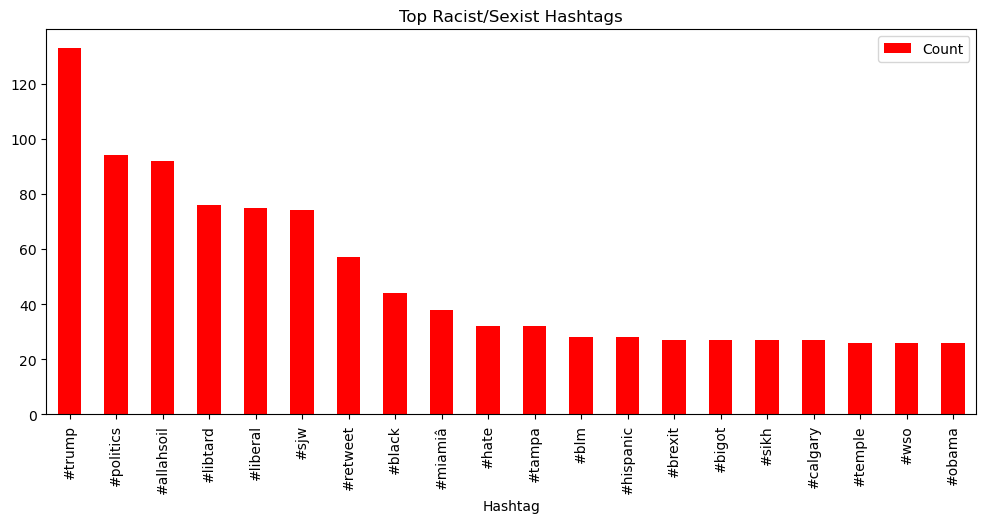

In [29]:
freq_racist_df = pd.DataFrame(freq_racist.most_common(20), columns=['Hashtag', 'Count'])
freq_normal_df = pd.DataFrame(freq_normal.most_common(20), columns=['Hashtag', 'Count'])
freq_racist_df.plot(x='Hashtag', y='Count', kind='bar', figsize=(12,5), 
                     title='Top Racist/Sexist Hashtags', color='red')
plt.show()


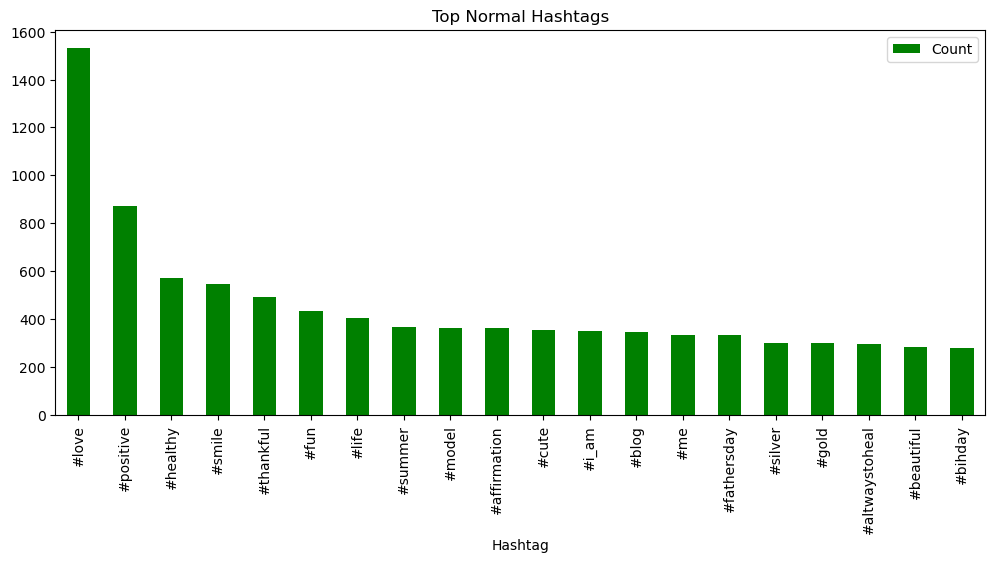

In [30]:
freq_normal_df.plot(x='Hashtag', y='Count', kind='bar', figsize=(12,5), 
                     title='Top Normal Hashtags', color='green')
plt.show()

In [31]:
from sklearn.feature_extraction.text import CountVectorizer
bow = CountVectorizer(max_features=1000)
X = bow.fit_transform(df['cleaned_tweet'])
bow_df = pd.DataFrame(X.toarray(), columns=bow.get_feature_names_out())
print("Shape:", bow_df.shape)
bow_df.head()

Shape: (31962, 1000)


,abl,about,absolut,accept,account,act,action,actual,ad,adapt,...,york,you,youll,young,your,yourself,youth,youtub,youv,yr
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
from sklearn.model_selection import train_test_split
y = df['label']
X = bow.fit_transform(df['cleaned_tweet'])
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2, 
                                                      random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (25569, 1000)
X_test shape: (6393, 1000)
y_train shape: (25569,)
y_test shape: (6393,)


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9374315657750665

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5937
           1       0.64      0.28      0.39       456

    accuracy                           0.94      6393
   macro avg       0.79      0.63      0.68      6393
weighted avg       0.93      0.94      0.93      6393



In [38]:
y_pred_prob = model.predict_proba(X_test)

print("Probabilities (first 5 rows):")
print(y_pred_prob[:5])

results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'prob_normal(0)': y_pred_prob[:, 0],
    'prob_racist(1)': y_pred_prob[:, 1]
})                                         

print(results_df.head(10))

Probabilities (first 5 rows):
[[9.99807572e-01 1.92428036e-04]
 [9.98129644e-01 1.87035630e-03]
 [9.84215707e-01 1.57842933e-02]
 [8.50267486e-01 1.49732514e-01]
 [9.79665534e-01 2.03344660e-02]]
   actual  predicted  prob_normal(0)  prob_racist(1)
0       0          0        0.999808        0.000192
1       0          0        0.998130        0.001870
2       0          0        0.984216        0.015784
3       0          0        0.850267        0.149733
4       0          0        0.979666        0.020334
5       0          0        0.984267        0.015733
6       0          0        0.972280        0.027720
7       0          0        0.985275        0.014725
8       0          0        0.998052        0.001948
9       0          0        0.965345        0.034655


In [39]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('bow.pkl', 'wb') as f:
    pickle.dump(bow, f)
print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!
